## Task_1 (Neural Network)

In [6]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.5.1+cu121'

In [7]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [8]:
# Task 1
import torch.nn as nn

# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [9]:
import pandas as pd

def train_and_evaluate_dataset(file_path, device):
    print(f"\n--- Processing Dataset: {file_path} ---")

    # 1. Load data
    df_current = pd.read_csv(file_path)
    print("First 5 rows of the dataset:")
    display(df_current.head())

    # 2. Data Preparation
    X = torch.tensor(df_current['x'].values, dtype=torch.float32).unsqueeze(dim=1).to(device)
    y = torch.tensor(df_current['y'].values, dtype=torch.float32).unsqueeze(dim=1).to(device)

    train_split = int(0.8 * len(X))
    X_train, y_train = X[:train_split], y[:train_split]
    X_test, y_test = X[train_split:], y[train_split:]

    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # 3. Model Training
    torch.manual_seed(42)
    model = LinearRegressionNN().to(device) # Re-instantiate model for each dataset

    loss_fn = nn.L1Loss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

    epochs = 500
    train_losses = []
    test_losses = []
    epoch_count = []

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.inference_mode():
            test_pred = model(X_test)
            test_loss = loss_fn(test_pred, y_test)

        if epoch % 50 == 0:
            train_losses.append(loss.item())
            test_losses.append(test_loss.item())
            epoch_count.append(epoch)

    print(f"Final Train loss: {train_losses[-1]:.4f} | Final Test loss: {test_losses[-1]:.4f}")

    # 4. Analyze Model Learning Capability and Appropriateness
    print("\n--- Analysis ---")
    if train_losses[-1] < 1.0 and test_losses[-1] < 1.0:
        print("The model demonstrates strong learning and is likely appropriate for this dataset, achieving very low training and test losses.")
    elif train_losses[-1] < 5.0 and test_losses[-1] < 10.0:
        print("The model is capable of learning from this dataset with moderate losses. It might be appropriate, but further analysis of the fit (e.g., plotting predictions) is recommended.")
    elif train_losses[-1] > test_losses[-1] and test_losses[-1] > 20:
        print("The model is learning, but the high test loss suggests potential issues, perhaps a non-linear relationship not well captured by a linear model.")
    elif test_losses[-1] > train_losses[-1] * 2 and train_losses[-1] < 10:
        print("The model shows signs of overfitting to the training data, indicating it might not generalize well, or the linear model is not appropriate for the underlying data pattern.")
    else:
        print("The model is learning but may not be the most appropriate. The losses indicate it's not capturing the full complexity of the data, potentially due to a non-linear relationship.")

    # 5. Visualizing Model Predictions (only for detailed inspection if needed)
    # This part is commented out as per the prompt's request for no detailed performance evaluation.
    model.eval()
    with torch.inference_mode():
        y_preds_train = model(X_train)
        y_preds_test = model(X_test)

    plt.figure(figsize=(10, 7))
    plt.scatter(X_train.cpu().numpy(), y_train.cpu().numpy(), c='b', s=4, label='Training data')
    plt.scatter(X_test.cpu().numpy(), y_test.cpu().numpy(), c='g', s=4, label='Testing data')
    plt.plot(X_train.cpu().numpy(), y_preds_train.cpu().numpy(), c='r', label='Model predictions (Train)')
    plt.plot(X_test.cpu().numpy(), y_preds_test.cpu().numpy(), c='orange', label='Model predictions (Test)')

    plt.title(f"Model Predictions vs Actual Data for {file_path.split('/')[-1]}")    
    plt.xlabel('X value')
    plt.ylabel('Y value')
    plt.legend()
    plt.grid(True)
    plt.show()


--- Processing Dataset: assignment-data.csv ---
First 5 rows of the dataset:


,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92


X_train shape: torch.Size([40, 1]), y_train shape: torch.Size([40, 1])
X_test shape: torch.Size([10, 1]), y_test shape: torch.Size([10, 1])
Final Train loss: 20.6227 | Final Test loss: 119.4409

--- Analysis ---
The model is learning but may not be the most appropriate. The losses indicate it's not capturing the full complexity of the data, potentially due to a non-linear relationship.


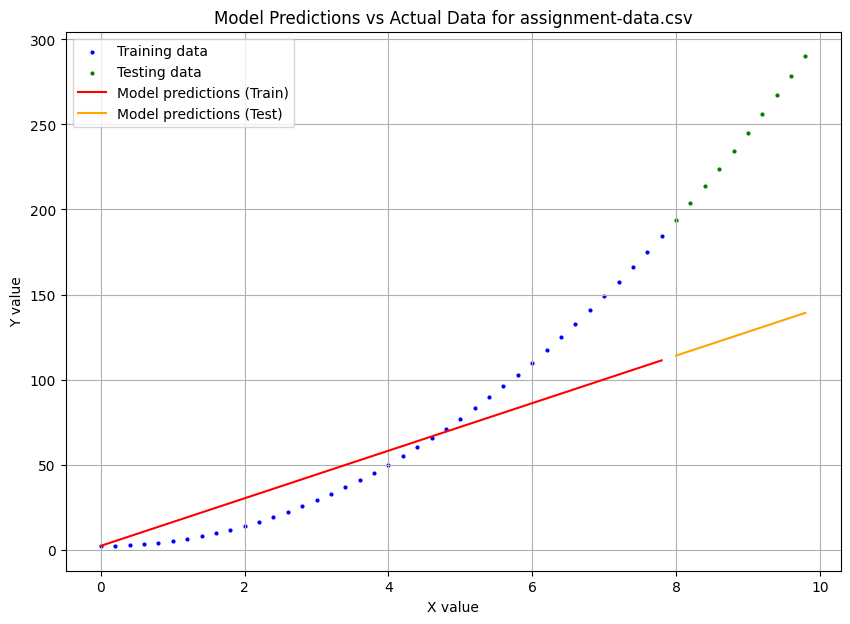


--- Processing Dataset: linear-regression-data1.csv ---
First 5 rows of the dataset:


,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356


X_train shape: torch.Size([40, 1]), y_train shape: torch.Size([40, 1])
X_test shape: torch.Size([10, 1]), y_test shape: torch.Size([10, 1])
Final Train loss: 0.0013 | Final Test loss: 0.0138

--- Analysis ---
The model demonstrates strong learning and is likely appropriate for this dataset, achieving very low training and test losses.


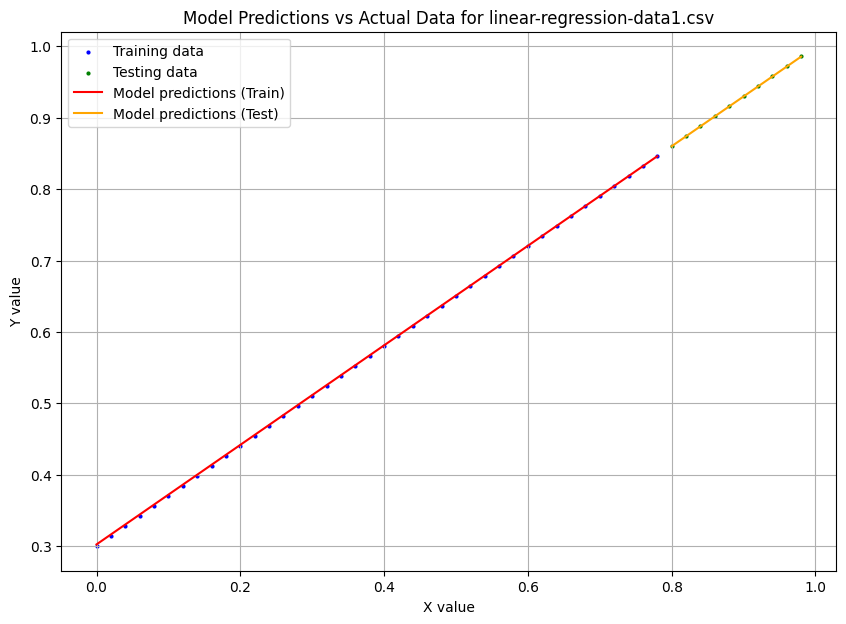


--- Processing Dataset: assignment-data2.csv ---
First 5 rows of the dataset:


,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00


X_train shape: torch.Size([79, 1]), y_train shape: torch.Size([79, 1])
X_test shape: torch.Size([20, 1]), y_test shape: torch.Size([20, 1])
Final Train loss: 154.8013 | Final Test loss: 505.9332

--- Analysis ---
The model is learning but may not be the most appropriate. The losses indicate it's not capturing the full complexity of the data, potentially due to a non-linear relationship.


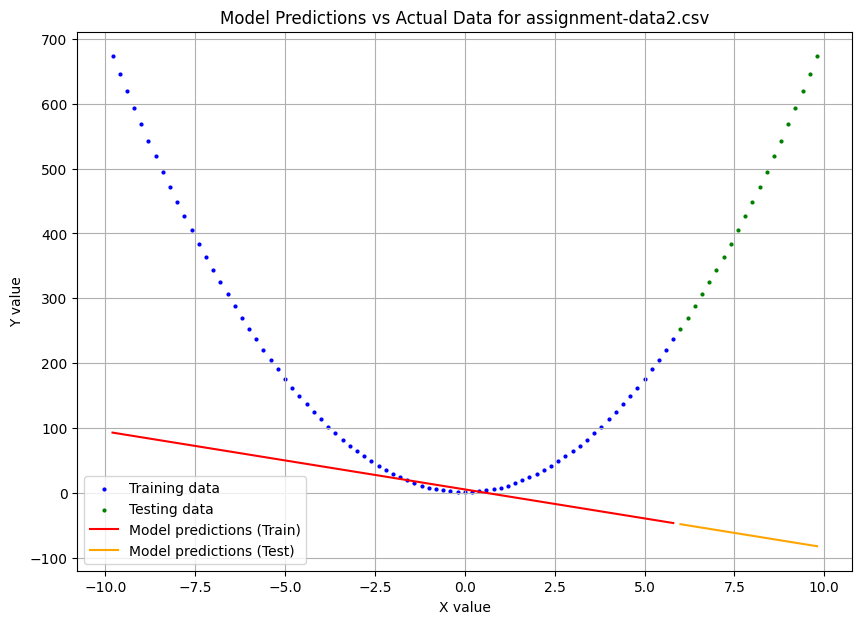

In [10]:
dataset_files = [
    'assignment-data.csv',
    'linear-regression-data1.csv',
    'assignment-data2.csv'
]

for dataset_path in dataset_files:
    train_and_evaluate_dataset(dataset_path, device)